In [63]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

In [43]:
data = pd.read_csv('pulse.txt', sep='\t', header=0)
data

,CB,EB,CA,EA
0,68.0,76,86.0,64
1,104.0,85,76.0,68
2,102.0,90,72.0,64
3,87.0,94,85.0,80
4,76.0,68,74.0,72
5,72.0,80,84.0,60
6,66.0,98,88.0,78
7,85.0,88,80.0,84
8,98.0,72,80.0,64
9,82.0,90,85.0,74


### Проверить выборки на нормальность графически и с помощью подходящего статистического критерия.

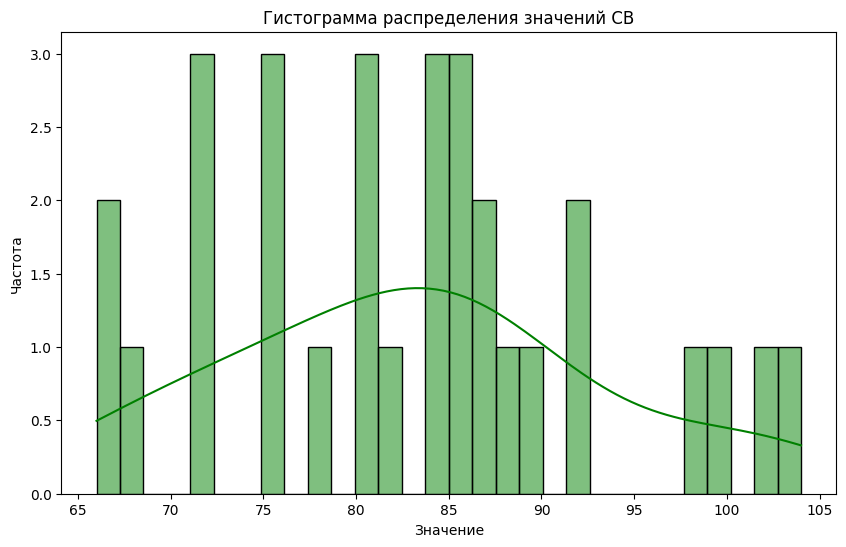

In [ ]:
data_CB = data['CB'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(data_CB, bins = 30, color='green', kde=True)
plt.title('Гистограмма распределения значений CB')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.show()


In [46]:
shapiro_stat, shapiro_p = stats.shapiro(data_CB)

print("Проверка нормальности (Шапиро-Уилка):")
print(f"Выборка CB: статистика = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

Проверка нормальности (Шапиро-Уилка):
Выборка CB: статистика = 0.9706, p-value = 0.5561


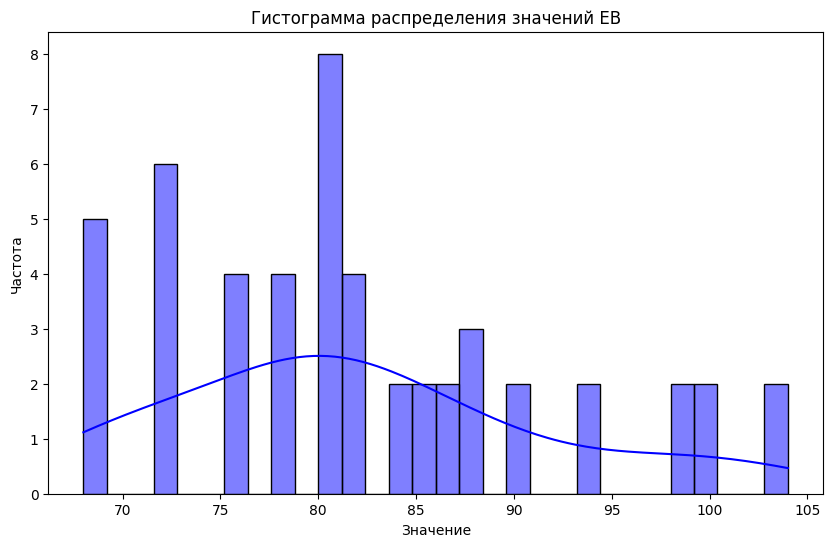

In [44]:
data_EB = data['EB'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(data_EB, bins = 30, color='blue', kde=True)
plt.title('Гистограмма распределения значений EB')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.show()

In [45]:
shapiro_stat, shapiro_p = stats.shapiro(data_EB)

print("Проверка нормальности (Шапиро-Уилка):")
print(f"Выборка EB: статистика = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

Проверка нормальности (Шапиро-Уилка):
Выборка EB: статистика = 0.9439, p-value = 0.0193


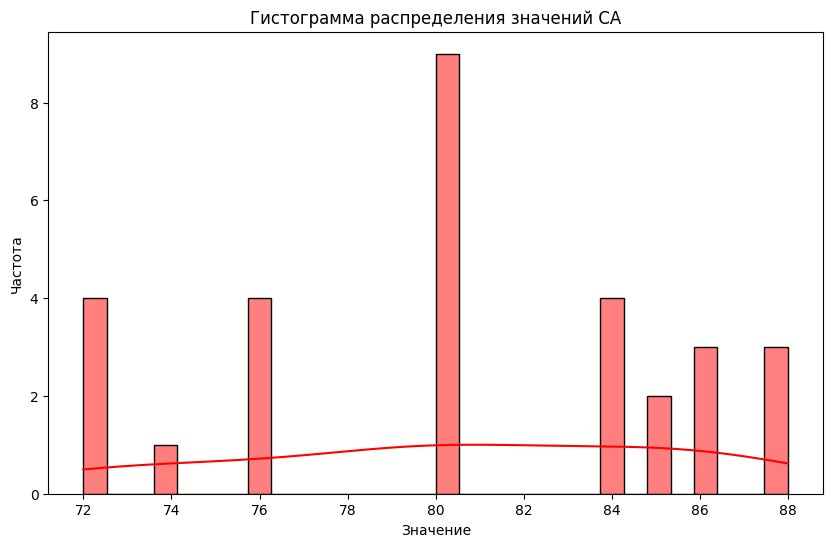

In [47]:
data_CA = data['CA'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(data_CA, bins = 30, color='red', kde=True)
plt.title('Гистограмма распределения значений CA')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.show()

In [48]:
shapiro_stat, shapiro_p = stats.shapiro(data_CA)

print("Проверка нормальности (Шапиро-Уилка):")
print(f"Выборка CA: статистика = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

Проверка нормальности (Шапиро-Уилка):
Выборка CA: статистика = 0.9193, p-value = 0.0258


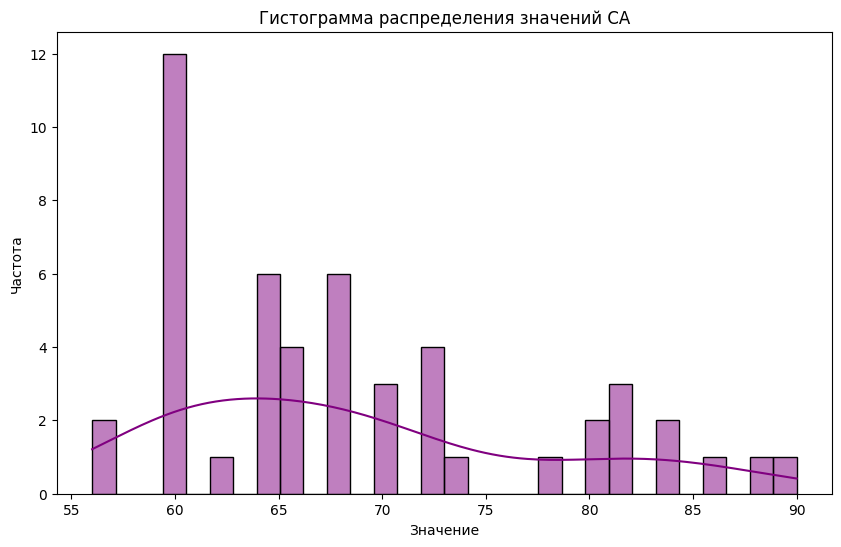

In [50]:
data_EA = data['EA'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(data_EA, bins = 30, color='purple', kde=True)
plt.title('Гистограмма распределения значений CA')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.show()

In [51]:
shapiro_stat, shapiro_p = stats.shapiro(data_EA)

print("Проверка нормальности (Шапиро-Уилка):")
print(f"Выборка EA: статистика = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

Проверка нормальности (Шапиро-Уилка):
Выборка EA: статистика = 0.9057, p-value = 0.0007


### Применив подходящие критерии сравнения групп определить однородность данных «до» и «после» для обеих групп испытуемых: «здоровых» и «пациентов» и построить коробки с усами.

CB: статистика = nan, p-value = nan
EB: статистика = 0.9439, p-value = 0.0193
CA: статистика = nan, p-value = nan
EA: статистика = 0.9057, p-value = 0.0007

Пациенты (до vs после): статистика = 134.5000, p-value = 0.1898
Здоровые (до vs после): статистика = 61.0000, p-value = 0.0000

Изменения (пациенты vs здоровые): статистика = 1127.0000, p-value = 0.0002


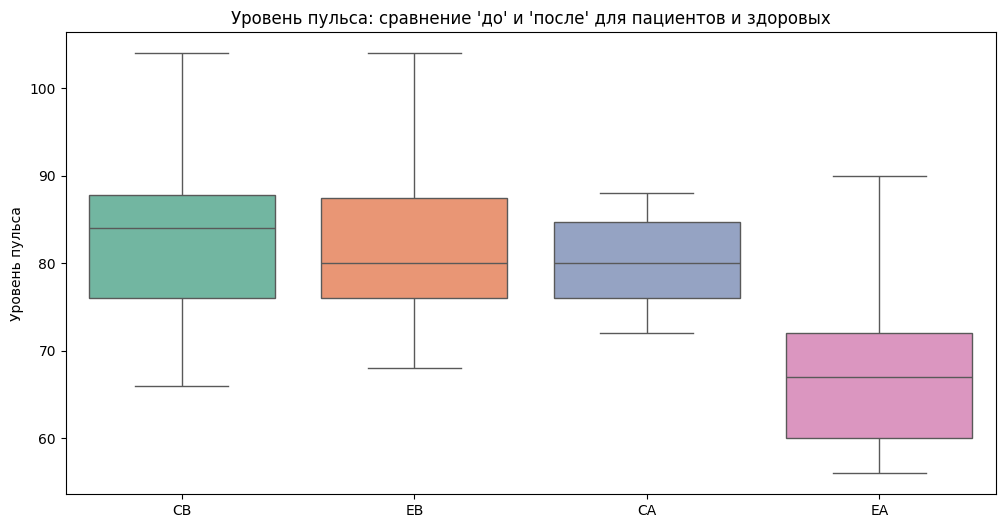

In [53]:
# Проверка нормальности (тест Шапиро-Уилка)
for group_name, group_data in data.items():
    stat, p = stats.shapiro(group_data)
    print(f"{group_name}: статистика = {stat:.4f}, p-value = {p:.4f}")

# Сравнение "до" и "после" для пациентов (CB vs CA)
stat_patients, p_patients = stats.wilcoxon(data_CB, data_CA)
print(f"\nПациенты (до vs после): статистика = {stat_patients:.4f}, p-value = {p_patients:.4f}")

# Сравнение "до" и "после" для здоровых (EB vs EA)
stat_healthy, p_healthy = stats.wilcoxon(data_EB, data_EA)
print(f"Здоровые (до vs после): статистика = {stat_healthy:.4f}, p-value = {p_healthy:.4f}")

# Сравнение изменений между группами (пациенты vs здоровые)
changes_patients = [a - b for a, b in zip(data_CA, data_CB)]
changes_healthy = [a - b for a, b in zip(data_EA, data_EB)]
stat_changes, p_changes = stats.mannwhitneyu(changes_patients, changes_healthy)
print(f"\nИзменения (пациенты vs здоровые): статистика = {stat_changes:.4f}, p-value = {p_changes:.4f}")

# Визуализация коробчатых диаграмм
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, palette="Set2")
plt.title("Уровень пульса: сравнение 'до' и 'после' для пациентов и здоровых")
plt.ylabel("Уровень пульса")
plt.show()

### Применив подходящие критерии сравнения групп определить однородность данных по группам испытуемых «здоровых» и «пациентов» для обеих случаев «до» и «после» и построить коробки с усами.

CB: статистика = nan, p-value = nan
EB: статистика = 0.9439, p-value = 0.0193
CA: статистика = nan, p-value = nan
EA: статистика = 0.9057, p-value = 0.0007

Сравнение «до» (CB vs EB): статистика = 807.0000, p-value = 0.5733
Сравнение «после» (CA vs EA): статистика = 1273.5000, p-value = 0.0000


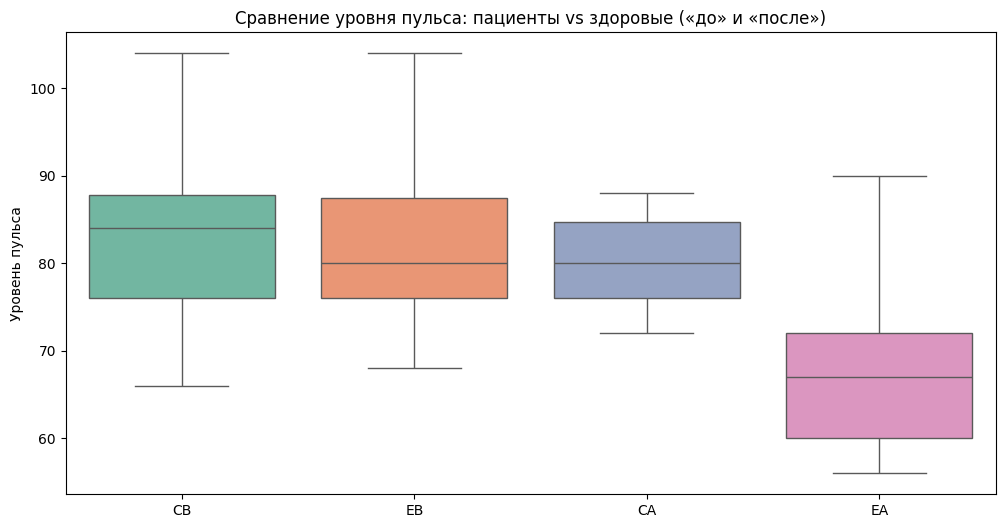

In [54]:
# Проверка нормальности
for group_name, group_data in data.items():
    stat, p = stats.shapiro(group_data)
    print(f"{group_name}: статистика = {stat:.4f}, p-value = {p:.4f}")

# Сравнение однородности «до» (CB vs EB)
stat_before, p_before = stats.mannwhitneyu(data_CB, data_EB)
print(f"\nСравнение «до» (CB vs EB): статистика = {stat_before:.4f}, p-value = {p_before:.4f}")

# Сравнение однородности «после» (CA vs EA)
stat_after, p_after = stats.mannwhitneyu(data_CA, data_EA)
print(f"Сравнение «после» (CA vs EA): статистика = {stat_after:.4f}, p-value = {p_after:.4f}")

# Визуализация коробчатых диаграмм
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, palette="Set2")
plt.title("Сравнение уровня пульса: пациенты vs здоровые («до» и «после»)")
plt.ylabel("Уровень пульса")
plt.show()

*Вывод* : 
1. Исходя из результатов анализа, можно с уверенностью сказать, что между группами «пациенты до» (CB) и «здоровые до» (EB) нет статистически значимых различий. Данные в этих группах можно считать однородными по уровню пульса до применения лекарства. Между группами «пациенты после» (CA) и «здоровые после» (EA) есть статистически значимые различия. Данные в этих группах __неоднородны__ по уровню пульса после применения лекарства.

2. У пациентов **нет статистически значимых изменений** уровня пульса до и после применения лекарства, это значит, что лекарство не оказало значимого влияния на пульс пациентов. У здоровых людей **есть статистически значимые** изменения уровня пульса до и после применения лекарства. Исходя из всего выше перечисленного, можно с уверенностью сказать, что это лекарство, никак не лечит болезнь, а наоборот вредит здоровым людям.


### Составить таблицу сопряженности признаков «Группа» и «Оценка».

In [57]:
data = pd.read_csv('grades.txt', sep='\t', header=0)
data

,Группа 1,Группа 2,Группа 3,Группа 4
0,4,4,4,5
1,5,4,4,5
2,3,3,4,3
3,4,4,4,5
4,3,5,3,4
5,3,4,3,5
6,3,5,5,4
7,4,4,4,5
8,3,4,5,5
9,3,4,4,5


In [59]:
data.isnull().sum()

Группа 1    0
Группа 2    0
Группа 3    0
Группа 4    0
dtype: int64

In [ ]:
data_long = pd.melt(
    data,
    var_name='Группа',
    value_name='Оценка',
    value_vars=['Группа 1', 'Группа 2', 'Группа 3', 'Группа 4']
)
contingency_table = pd.crosstab(data_long['Группа'], data_long['Оценка'])

contingency_table

Оценка,3,4,5
Группа,,,
Группа 1,17,11,2
Группа 2,12,15,3
Группа 3,13,12,5
Группа 4,4,7,19


In [66]:
chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)

# Проверяем, есть ли ожидаемые частоты меньше 5
should_use_fisher = (expected < 5).any()

# Выбираем подходящий критерий
if should_use_fisher:
    _, p_fisher = fisher_exact(contingency_table)
    p_value = p_fisher
    test_name = "Точный критерий Фишера"
else:
    p_value = p_chi2
    test_name = "Критерий хи-квадрат"
    
p_value, test_name, expected

(np.float64(2.0284374957509765e-06),
 'Критерий хи-квадрат',
 array([[11.5 , 11.25,  7.25],
        [11.5 , 11.25,  7.25],
        [11.5 , 11.25,  7.25],
        [11.5 , 11.25,  7.25]]))

*Вывод*: p-value < 0.05 означает, что мы отвергаем нулевую гипотезу об отсутствии связи между признаками «Группа» и «Оценка». Статистически значимая связь между группой и оценкой существует.
